# Goal of this notebook - 
Compare:

Random Forest (Baseline)
vs
XGBoost (Advanced)

and determine:

* Accuracy
* F1 Score
* Precision
* Recall

In [2]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

from xgboost import XGBClassifier

## Load Engineered Dataset

In [3]:
DATA_PATH = Path(
    "../data/processed/pairwise_engineered.csv"
)

df = pd.read_csv(DATA_PATH)

print(df.shape)

(10000, 156)


## Create Balanced Labels

In [4]:
def classify_compatibility(score):

    if score < 71.48:
        return "Low"

    elif score < 77.78:
        return "Medium"

    else:
        return "High"

df["compatibility_label"] = (df["compatibility_score"].apply(classify_compatibility))

df["compatibility_label"].value_counts()

C:\Users\aarus_gzbjvu0\AppData\Local\Temp\ipykernel_24016\1642944491.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["compatibility_label"] = (df["compatibility_score"].apply(classify_compatibility))


compatibility_label
High      3409
Medium    3299
Low       3292
Name: count, dtype: int64

## Remove Obsolete Features

In [5]:
obsolete_features = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in [
        "student_id",
        "course",
        "year_of_study",
        "hostel_block"
    ])
]

df = df.drop(columns=obsolete_features, errors="ignore")

print("Removed obsolete features:")
print(obsolete_features)
print("New shape:", df.shape)

Removed obsolete features:
[]
New shape: (10000, 157)


## One-Hot Encode

In [6]:
categorical_columns = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

categorical_columns.remove(
    "compatibility_label"
)

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=False
)

In [7]:
# Inspect remaining study-related features after encoding

study_related = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in [
        "study",
        "academic",
        "silence"
    ])
]

print("Study/academic-related features:")
print("\n".join(study_related))
print("\nTotal:", len(study_related))

Study/academic-related features:
study_hours_1
silence_requirement_1
self_talking_study_1
academic_seriousness_1
study_hours_2
silence_requirement_2
self_talking_study_2
academic_seriousness_2
study_hours_diff
academic_seriousness_diff
study_hours_similarity
academic_seriousness_similarity
study_time_preference_1_Afternoon
study_time_preference_1_Evening
study_time_preference_1_Morning
study_time_preference_1_Night
study_time_preference_2_Afternoon
study_time_preference_2_Evening
study_time_preference_2_Morning
study_time_preference_2_Night

Total: 20


In [8]:
# Remove old college-specific study environment features
features_to_remove = [
    "silence_requirement_1",
    "silence_requirement_2",
    "self_talking_study_1",
    "self_talking_study_2",
]

# Remove all one-hot encoded study-time preference columns
features_to_remove += [
    col for col in df.columns
    if col.startswith("study_time_preference_")
]

df = df.drop(columns=features_to_remove, errors="ignore")

print("Removed:")
print(features_to_remove)

print("\nRemaining study/academic features:")
print([
    col for col in df.columns
    if any(keyword in col.lower() for keyword in [
        "study_hours",
        "academic_seriousness"
    ])
])

print("\nNew shape:", df.shape)

Removed:
['silence_requirement_1', 'silence_requirement_2', 'self_talking_study_1', 'self_talking_study_2', 'study_time_preference_1_Afternoon', 'study_time_preference_1_Evening', 'study_time_preference_1_Morning', 'study_time_preference_1_Night', 'study_time_preference_2_Afternoon', 'study_time_preference_2_Evening', 'study_time_preference_2_Morning', 'study_time_preference_2_Night']

Remaining study/academic features:
['study_hours_1', 'academic_seriousness_1', 'study_hours_2', 'academic_seriousness_2', 'study_hours_diff', 'academic_seriousness_diff', 'study_hours_similarity', 'academic_seriousness_similarity']

New shape: (10000, 183)


## Feature and  Target

In [9]:
X = df.drop(
    columns=[
        "compatibility_score",
        "compatibility_label"
    ]
)

y = df["compatibility_label"]

print(X.shape)

(10000, 181)


## Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #keeps class balance in train and test sets
)

## Random Forest Baseline

In [11]:
rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)
rf_predictions = rf.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted"
)

print("Model Training Completed")
print("RF Accuracy:", rf_accuracy)
print("RF F1:", rf_f1)

Model Training Completed
RF Accuracy: 0.8195
RF F1: 0.8182860605816136


In [12]:
print(df.shape)
print(X.shape)
print(X_train.shape)

(10000, 183)
(10000, 181)
(8000, 181)


In [13]:
import xgboost

print(xgboost.__version__)

3.2.0


XGBoost does NOT accept:

High
Medium
Low

It needs integers.

In [14]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y)

print(target_encoder.classes_)

['High' 'Low' 'Medium']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [16]:
xgb_model = XGBClassifier(

    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

In [17]:
xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegresso

In [18]:
xgb_predictions = xgb_model.predict(
    X_test
)

In [19]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

xgb_f1 = f1_score(
    y_test,
    xgb_predictions,
    average="weighted"
)

print(
    "XGB Accuracy:",
    round(xgb_accuracy, 4)
)

print(
    "XGB F1:",
    round(xgb_f1, 4)
)

XGB Accuracy: 0.8855
XGB F1: 0.8865


In [20]:
print(
    classification_report(
        y_test,
        xgb_predictions
    )
)

              precision    recall  f1-score   support

           0       0.93      0.90      0.91       682
           1       0.93      0.89      0.91       658
           2       0.80      0.86      0.83       660

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



In [21]:
# Comparison Table
comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        rf_accuracy,
        xgb_accuracy
    ],

    "F1 Score": [
        rf_f1,
        xgb_f1
    ]
})

comparison

,Model,Accuracy,F1 Score
0,Random Forest,0.8195,0.818286
1,XGBoost,0.8855,0.886482


In [22]:
print("X shape:", X.shape)
print("X_train shape:", X_train.shape)
print("XGBoost features:", xgb_model.n_features_in_)

X shape: (10000, 181)
X_train shape: (8000, 181)
XGBoost features: 181


## Feature Importance

In [23]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance.head(20)

,Feature,Importance
138,behavioral_alignment_score,0.044675
111,noise_sleep_tolerance_diff,0.023793
135,social_compatibility,0.022590
128,noise_sleep_tolerance_similarity,0.020628
112,schedule_consistency_diff,0.019858
119,cleanliness_score_similarity,0.018822
121,privacy_preference_similarity,0.017850
104,privacy_preference_diff,0.017285
102,cleanliness_score_diff,0.016908
129,schedule_consistency_similarity,0.014973


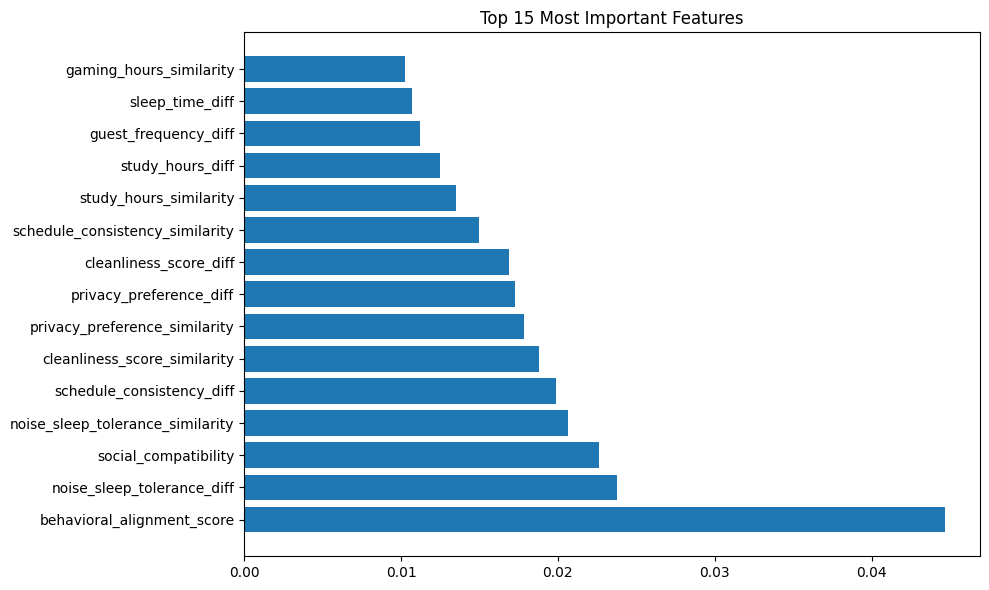

In [24]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 15 Most Important Features"
)

plt.tight_layout()

plt.show()

Feature importance analysis revealed that behavioral alignment, lifestyle similarity, sleep schedules, cleanliness preferences, privacy expectations, and social habits were the strongest predictors of roommate compatibility, outperforming demographic attributes.

## Importing SHAP
SHAP (SHapley Additive Explanations) is an Explainable AI (XAI) technique based on cooperative game theory.

Instead of just saying:

Compatibility = High

SHAP tells us:

Why did the model predict High?

It computes how much each feature contributes to the prediction.

https://www.youtube.com/watch?v=MQ6fFDwjuco

In [25]:
import shap

We don't want to remove features just because XGBoost assigned them low importance.

SHAP gives feature contributions for individual predictions, which is much more reliable for deciding what to keep or remove.

After SHAP, we'll move to scientific feature selection, retrain the model, and compare whether we can maintain or even improve the current 84.6% accuracy with fewer features.

In [26]:
# Create Explainer

explainer = shap.TreeExplainer(
    xgb_model
)

In [27]:
# Calculate SHAP Values
shap_values = explainer.shap_values(
    X_test
)
shap_values

array([[[-7.3990645e-04,  6.1082281e-03, -5.5643421e-04],
        [ 2.0693000e-04, -4.3946720e-04, -2.2071865e-04],
        [-2.9259019e-03,  5.5076554e-04, -2.9126736e-03],
        ...,
        [ 1.6642200e-03,  1.4017727e-03, -1.0096894e-03],
        [-5.1364265e-03,  3.8160797e-06,  3.7087018e-03],
        [-7.6617009e-04, -3.8971243e-04,  4.7303638e-03]],

       [[ 1.8205487e-03,  1.8344218e-03,  9.7586121e-03],
        [-7.3201647e-03,  9.1292635e-03, -1.5051659e-02],
        [ 1.5744495e-03, -1.2607776e-02,  8.4012253e-03],
        ...,
        [ 1.4571584e-03, -5.6525059e-03, -1.0422738e-02],
        [ 1.2239752e-03, -8.4283407e-04, -1.4400549e-04],
        [-7.5556515e-03,  1.8393925e-03,  1.5326897e-03]],

       [[ 8.1850439e-03,  5.7781930e-03, -4.0453551e-03],
        [-5.4702405e-03,  2.0466608e-03, -1.1538523e-02],
        [ 5.7523968e-03, -3.3896959e-03, -1.4673259e-02],
        ...,
        [-5.4352928e-04,  5.8959927e-03, -5.6262623e-04],
        [ 1.8407704e-04,  8.5

### Summary Plot

This plot answers:

Which features matter the most?

Do high values increase or decrease compatibility?

How are predictions distributed?

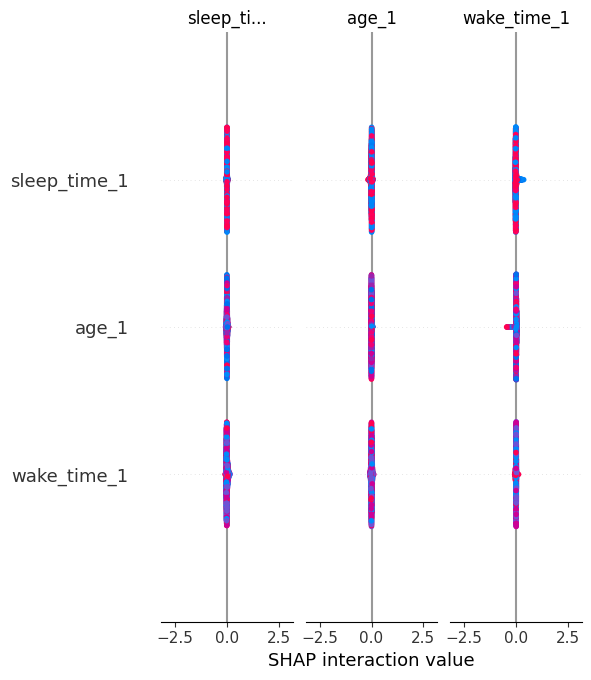

In [28]:
shap.summary_plot(shap_values, X_test)

### Bar Plot
This provides a global ranking of feature importance using SHAP values.

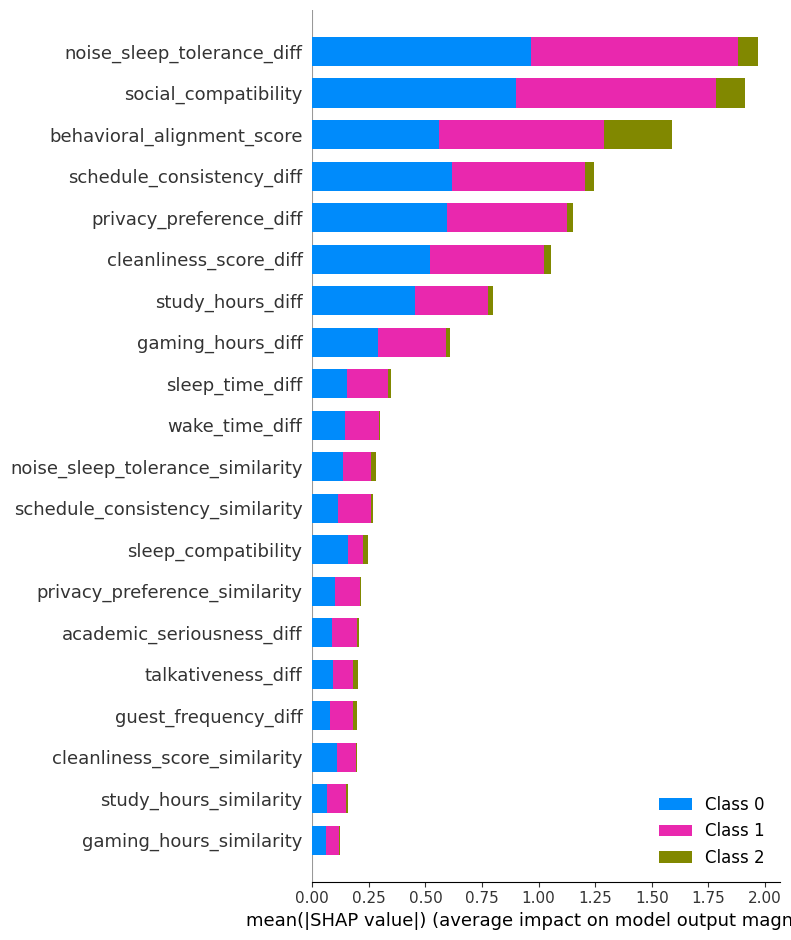

In [29]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

### Explain One Prediction
Let's inspect one roommate pair

In [30]:
print(type(shap_values))
print(shap_values.shape if hasattr(shap_values, "shape") else shap_values.values.shape)

<class 'numpy.ndarray'>
(2000, 181, 3)


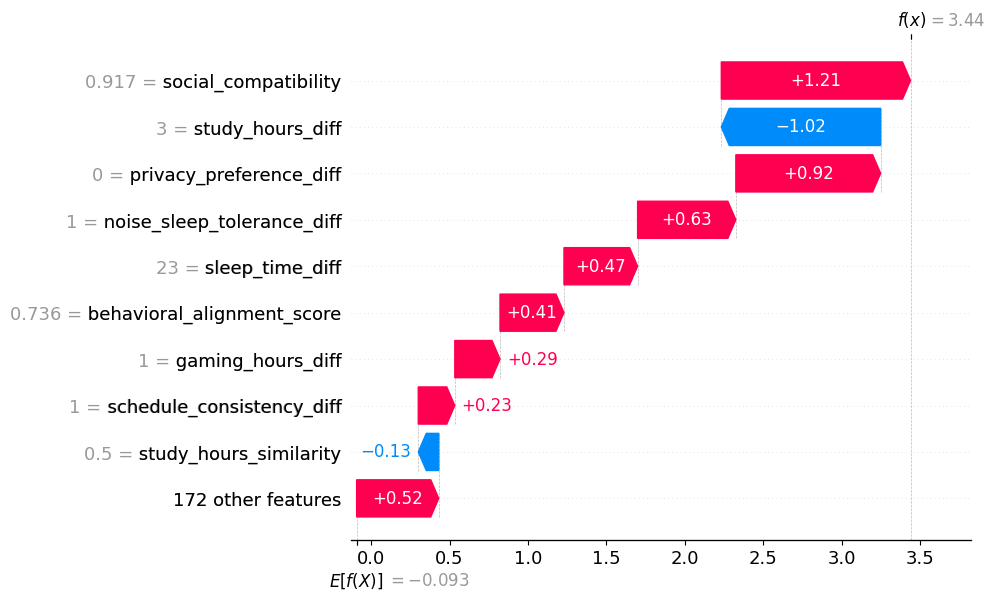

In [31]:
sample_index = 0
class_index = xgb_predictions[sample_index]

explanation = shap.Explanation(
    values=shap_values[sample_index, :, class_index],
    base_values=explainer.expected_value[class_index],
    data=X_test.iloc[sample_index].values,
    feature_names=X_test.columns
)

shap.plots.waterfall(explanation)

This tells us exactly why that specific prediction was made.

Previously we could only say:

Prediction = High Compatibility

Now we can say:

The prediction was primarily influenced by differences in sleep schedules, social compatibility, and noise tolerance, while behavioral alignment slightly reduced the confidence.

### Dependence Plot
This reveals how changes in behavioral alignment affect the prediction.

In [32]:
print(type(shap_values))

<class 'numpy.ndarray'>


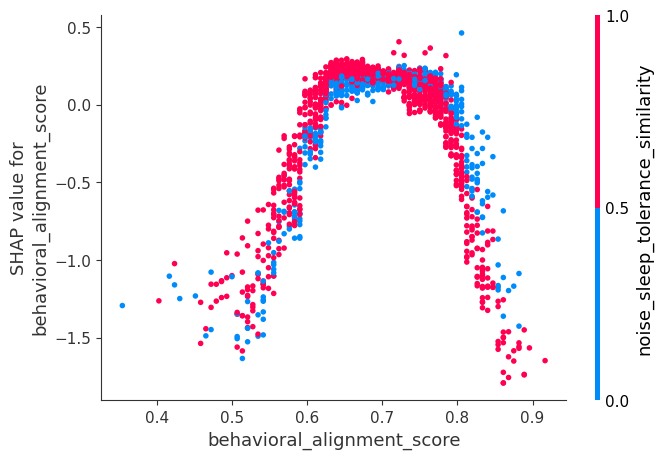

In [33]:
class_index = 2

shap.dependence_plot(
    "behavioral_alignment_score",
    shap_values[:, :, class_index],
    X_test
)

The SHAP dependence plot demonstrates that behavioral alignment has a nonlinear influence on roommate compatibility predictions. Low behavioral alignment significantly reduces the predicted compatibility score, while moderate alignment contributes positively. The interaction coloring further suggests that noise tolerance similarity influences the effect of behavioral alignment, indicating that compatibility depends on combinations of behavioral traits rather than any single feature alone.

In [34]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("Number of classes:", len(shap_values))
    print(shap_values[0].shape)
else:
    print(shap_values.shape)

<class 'numpy.ndarray'>
(2000, 181, 3)


# Model-Based Feature Selection

In [35]:
from sklearn.feature_selection import SelectFromModel

In [36]:
selector = SelectFromModel(
    estimator=xgb_model,
    threshold="median",
    prefit=True
)

In [37]:
X_selected = selector.transform(X)

c:\Users\aarus_gzbjvu0\OneDrive\Desktop\hostel_pg\Roommate_compatibility\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [38]:
selected_features = X.columns[selector.get_support()]

In [39]:
print("Original Features :", X.shape[1])
print("Selected Features :", len(selected_features))

Original Features : 181
Selected Features : 91


In [40]:
selected_features # This will list all the features the model decided to keep.

Index(['sleep_time_1', 'wake_time_1', 'alarm_count_1', 'snooze_frequency_1',
       'noise_sleep_tolerance_1', 'study_hours_1', 'cleanliness_score_1',
       'talkativeness_1', 'guest_frequency_1', 'privacy_preference_1',
       'temperature_preference_1', 'conflict_tolerance_1',
       'communication_respect_1', 'adaptability_1', 'schedule_consistency_1',
       'gaming_hours_1', 'music_volume_1', 'food_smell_tolerance_1',
       'gym_frequency_1', 'religious_practice_frequency_1', 'sleep_time_2',
       'wake_time_2', 'lights_off_time_2', 'study_hours_2',
       'cleanliness_score_2', 'room_cleaning_frequency_2',
       'bathing_frequency_2', 'towel_management_2', 'phone_call_frequency_2',
       'guest_frequency_2', 'friendship_expectation_2',
       'boundary_importance_2', 'temperature_preference_2',
       'negativity_level_2', 'music_volume_2', 'gym_frequency_2',
       'expense_responsibility_2', 'sleep_time_diff', 'wake_time_diff',
       'study_hours_diff', 'academic_seriousn

In [41]:
forbidden_keywords = [
    "student_id",
    "course",
    "year_of_study",
    "hostel_block",
    "study_time_preference",
    "silence_requirement",
    "self_talking_study"
]

forbidden_selected = [
    feature for feature in selected_features
    if any(keyword in feature for keyword in forbidden_keywords)
]

print("Forbidden features selected:")
print(forbidden_selected)

Forbidden features selected:
[]


# Retraining XGBoost on Selected Features
Can we maintain or improve our performance using only 104 features? Let's see.

In [42]:
X_selected = df[selected_features]

In [43]:
from sklearn.preprocessing import LabelEncoder 

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(
    df["compatibility_label"]
)

print(label_encoder.classes_)

['High' 'Low' 'Medium']


In [44]:
from sklearn.model_selection import train_test_split
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected,
    y_encoded,
    test_size = 0.2,
    random_state = 42,
    stratify = y_encoded
)

## Train XGBoost

In [45]:
xgb_selected = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_selected.fit(
    X_train_selected,
    y_train_selected
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegresso

In [46]:
print(y[:10])

0      High
1    Medium
2    Medium
3    Medium
4    Medium
5       Low
6       Low
7       Low
8    Medium
9    Medium
Name: compatibility_label, dtype: str


## Evaluating the selected model

In [47]:
selected_predictions = xgb_selected.predict(
    X_test_selected
)

In [48]:
# Accuracy and F1

from sklearn.metrics import accuracy_score, f1_score

selected_accuracy = accuracy_score(
    y_test_selected,
    selected_predictions
)

selected_f1 = f1_score(
    y_test_selected,
    selected_predictions,
    average="weighted"
)

print(f"Accuracy : {selected_accuracy:.4f}")
print(f"F1 Score : {selected_f1:.4f}")

Accuracy : 0.9000
F1 Score : 0.9008


In [49]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_selected,
        selected_predictions
    )
)

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       682
           1       0.94      0.90      0.92       658
           2       0.82      0.88      0.85       660

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000



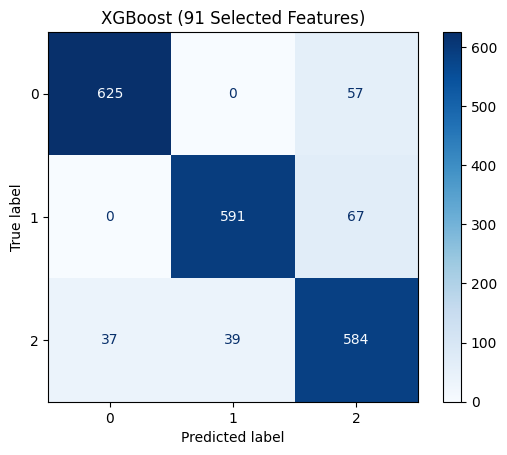

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_selected,
    selected_predictions,
    cmap="Blues"
)

plt.title(f"XGBoost ({len(selected_features)} Selected Features)")
plt.show()

In [51]:
comparison = pd.DataFrame({
    "Model": [
        "XGBoost (181 Features)",
        f"XGBoost ({len(selected_features)} Features)"
    ],

    "Accuracy": [
        xgb_accuracy,
        selected_accuracy
    ],

    "F1 Score": [
        xgb_f1,
        selected_f1
    ]
})

comparison

,Model,Accuracy,F1 Score
0,XGBoost (181 Features),0.8855,0.886482
1,XGBoost (91 Features),0.9000,0.900829


### Feature Selection Analysis

Model-based feature selection using XGBoost reduced the feature space from 181 to 91 features while improving the model's predictive performance. The optimized model achieved an accuracy of 90.0% and a weighted F1-score of 0.901, compared to 88.55% accuracy and 0.887 weighted F1-score using the full feature set. This indicates that removing low-importance features reduced noise and improved generalization while retaining the most informative features for roommate compatibility prediction.

# Cross-Validation
If I split the data differently, will my model still perform well?

Since this is a classification problem with three classes (High, Medium, Low), we should use StratifiedKFold instead of regular KFold.

In [52]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

In [53]:
# Creating the Cross Validator
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [54]:
# Accuracy Cross Validation
accuracy_scores = cross_val_score(
    estimator = xgb_selected,
    X = X_selected,
    y=y_encoded,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

In [55]:
# Printing Results
print("Accuracy Scores: ")
print(accuracy_scores)
print()

print("Mean Accuracy : {:.4f}".format(accuracy_scores.mean()))
print("Std Deviation : {:.4f}".format(accuracy_scores.std()))

Accuracy Scores: 
[0.8885 0.8775 0.8875 0.892  0.885 ]

Mean Accuracy : 0.8861
Std Deviation : 0.0049


In [56]:
# F1 Cross Validation
f1_scores = cross_val_score(

    estimator=xgb_selected,

    X=X_selected,

    y=y_encoded,

    cv=cv,

    scoring="f1_weighted",

    n_jobs=-1
)

In [57]:
# Printing F1
print("Weighted F1 Scores:")

print(f1_scores)

print()

print("Mean F1 : {:.4f}".format(f1_scores.mean()))

print("Std Deviation : {:.4f}".format(f1_scores.std()))

Weighted F1 Scores:
[0.88936519 0.87819596 0.88858726 0.89291341 0.88562505]

Mean F1 : 0.8869
Std Deviation : 0.0049


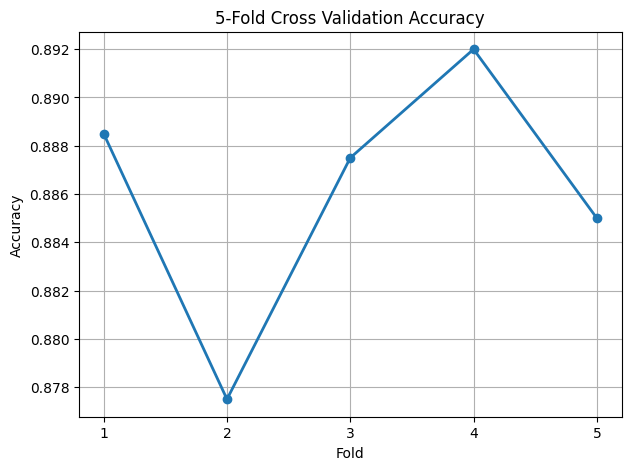

In [58]:
# Visualizing
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    range(1,6),
    accuracy_scores,
    marker="o",
    linewidth=2
)

plt.xticks(range(1,6))
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross Validation Accuracy")
plt.grid(True)
plt.show()

### Cross-Validation Analysis

The optimized XGBoost model was evaluated using Stratified 5-Fold Cross-Validation to assess its robustness across different data splits. The model achieved a mean accuracy of 88.61% with a standard deviation of 0.49% across the five folds. The mean weighted F1-score was 88.69%, also with a standard deviation of 0.49%.

The relatively small variation between folds indicates that the model performs consistently across different subsets of the dataset. This suggests that the selected feature set provides stable predictive information and that the model generalizes well beyond a single train-test split.

# Hyperparameter Tuning 
  ### RandomizedSearchCV

In [59]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

In [60]:
# Defining parameter grid
param_grid = {

    "n_estimators": [100, 200, 300, 400, 500],

    "max_depth": [3, 4, 5, 6, 7, 8],

    "learning_rate": [0.01, 0.03, 0.05, 0.1],

    "subsample": [0.7, 0.8, 0.9, 1.0],

    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],

    "min_child_weight": [1, 3, 5],

    "gamma": [0, 0.1, 0.3, 0.5]
}

In [61]:
# Creating Base Model
xgb = XGBClassifier(
    objective = "multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

In [62]:
# Creating Randomized Search

random_search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=param_grid,

    n_iter=30,

    scoring="accuracy",

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

In [63]:
# Training
random_search.fit(

    X_train_selected,
    y_train_selected
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=3, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichret

In [64]:
print("Best Parameters:\n")

print(random_search.best_params_)

Best Parameters:

{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}


In [65]:
print("Best CV Accuracy:")

print(random_search.best_score_)

Best CV Accuracy:
0.8924999999999998


In [66]:
# Best Model
best_xgb = random_search.best_estimator_

In [67]:
# Final Evaluation
best_predictions = best_xgb.predict(
    X_test_selected
)

In [68]:
from sklearn.metrics import accuracy_score, f1_score

best_accuracy = accuracy_score(

    y_test_selected,

    best_predictions
)

best_f1 = f1_score(

    y_test_selected,

    best_predictions,

    average="weighted"
)

print("Accuracy :", best_accuracy)

print("F1 Score :", best_f1)

Accuracy : 0.9035
F1 Score : 0.9040474103771153


In [69]:
comparison = pd.DataFrame({

    "Model": [
    "XGBoost (181 Features)",
    "XGBoost (91 Selected Features)",
    "XGBoost (91 Features + Tuned)"
    ],

"Accuracy": [
    xgb_accuracy,
    selected_accuracy,
    best_accuracy
],

"F1 Score": [
    xgb_f1,
    selected_f1,
    best_f1
]
})

comparison

,Model,Accuracy,F1 Score
0,XGBoost (181 Features),0.8855,0.886482
1,XGBoost (91 Selected Features),0.9000,0.900829
2,XGBoost (91 Features + Tuned),0.9035,0.904047


Hyperparameter tuning using RandomizedSearchCV further improved the performance of the feature-selected XGBoost model. After reducing the feature space from 181 to 91 features, the tuned model achieved an accuracy of 90.35% and a weighted F1-score of 0.9040, outperforming both the original and feature-selected baseline models. This demonstrates that combining model-based feature selection with systematic hyperparameter optimization improved predictive performance while using fewer features.

In [73]:
print("Model type:", type(best_xgb))
print("Selected features:", len(selected_features))
print("Selected features type:", type(selected_features))
print("First 10 features:")
print(list(selected_features[:10]))

Model type: <class 'xgboost.sklearn.XGBClassifier'>
Selected features: 91
Selected features type: <class 'pandas.Index'>
First 10 features:
['sleep_time_1', 'wake_time_1', 'alarm_count_1', 'snooze_frequency_1', 'noise_sleep_tolerance_1', 'study_hours_1', 'cleanliness_score_1', 'talkativeness_1', 'guest_frequency_1', 'privacy_preference_1']


In [75]:
import joblib

saved_features = joblib.load("models/selected_features.pkl")
saved_model = joblib.load("models/final_xgboost_model.pkl")

print("Saved model:", type(saved_model))
print("Saved feature count:", len(saved_features))
print("First 10 saved features:")
print(saved_features[:10])

Saved model: <class 'xgboost.sklearn.XGBClassifier'>
Saved feature count: 91
First 10 saved features:
['sleep_time_1', 'wake_time_1', 'alarm_count_1', 'snooze_frequency_1', 'noise_sleep_tolerance_1', 'study_hours_1', 'cleanliness_score_1', 'talkativeness_1', 'guest_frequency_1', 'privacy_preference_1']


In [76]:
import joblib

features = joblib.load("models/selected_features.pkl")

print("COUNT:", len(features))

for i, feature in enumerate(features, 1):
    print(f"{i}. {feature}")

COUNT: 91
1. sleep_time_1
2. wake_time_1
3. alarm_count_1
4. snooze_frequency_1
5. noise_sleep_tolerance_1
6. study_hours_1
7. cleanliness_score_1
8. talkativeness_1
9. guest_frequency_1
10. privacy_preference_1
11. temperature_preference_1
12. conflict_tolerance_1
13. communication_respect_1
14. adaptability_1
15. schedule_consistency_1
16. gaming_hours_1
17. music_volume_1
18. food_smell_tolerance_1
19. gym_frequency_1
20. religious_practice_frequency_1
21. sleep_time_2
22. wake_time_2
23. lights_off_time_2
24. study_hours_2
25. cleanliness_score_2
26. room_cleaning_frequency_2
27. bathing_frequency_2
28. towel_management_2
29. phone_call_frequency_2
30. guest_frequency_2
31. friendship_expectation_2
32. boundary_importance_2
33. temperature_preference_2
34. negativity_level_2
35. music_volume_2
36. gym_frequency_2
37. expense_responsibility_2
38. sleep_time_diff
39. wake_time_diff
40. study_hours_diff
41. academic_seriousness_diff
42. cleanliness_score_diff
43. organization_score_di

In [74]:
import os
from pathlib import Path
import joblib

project_root = Path(os.getcwd()).parent

model_dir = project_root / "models"
model_dir.mkdir(exist_ok=True)

joblib.dump(best_xgb, "models/final_xgboost_model.pkl")
joblib.dump(label_encoder, "models/label_encoder.pkl")
joblib.dump(selected_features.tolist(), "models/selected_features.pkl")

print("Models saved successfully!")
print(model_dir)

Models saved successfully!
c:\Users\aarus_gzbjvu0\OneDrive\Desktop\hostel_pg\Roommate_compatibility\models


In [71]:
print(type(selected_features))

<class 'pandas.Index'>


In [72]:
import sys
import sklearn
import pandas
import xgboost

print("Python:", sys.version)
print("sklearn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("xgboost:", xgboost.__version__)

Python: 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
sklearn: 1.9.0
pandas: 3.0.3
xgboost: 3.2.0
